In [131]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os

import pandas as pd

import legwork as lw
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

%config InlineBackend.figure_format = 'retina'

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [15]:
def bpp_to_source(bpp, dist=8 * u.kpc, **kwargs):
    s = lw.source.Source(
        m_1=bpp["mass_1"].values * u.Msun,
        m_2=bpp["mass_2"].values * u.Msun,
        ecc=bpp["ecc"].values,
        a=bpp["sep"].values * u.Rsun,
        dist=np.ones_like(bpp["sep"]) * dist, interpolate_g=kwargs.pop("interpolate_g", True),
        **kwargs
    )
    return s

In [2]:
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"
file = "NSWD_Z_0.01052.h5"
# file = "NSWD_Z_0.0002.h5"
initC = cosmic.output.load_initC(f"{FOLDER}/stroopwafel_files/{file}", key="initC")
bpp = pd.read_hdf(f"{FOLDER}/stroopwafel_files/{file}", key="bpp")

In [3]:
k_lo = [13]
k_hi = [10, 11, 12]
dco_type = "NSWD"
mask = ((
    (bpp["kstar_1"].isin(k_lo)) & (bpp["kstar_2"].isin(k_hi))
) | (
    (bpp["kstar_1"].isin(k_hi)) & (bpp["kstar_2"].isin(k_lo))
)) & (bpp["sep"] > 0)
if mask.sum() == 0:
    print(f"    No {dco_type} systems found in this file.")
formation_rows = bpp[mask].drop_duplicates(subset="bin_num")
post_dco_rlof_rows = bpp[mask & (bpp["evol_type"] == 3)].drop_duplicates(subset="bin_num")
final_rows = bpp[mask].drop_duplicates(subset="bin_num", keep="last")

In [4]:
formation_rows

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
527,298.947274,1.329429,0.531034,13,11,0.522877,0.032126,0.0,5.820684e-05,0.086827,...,0.0,0.051853,0.0,225.286434,0.0,37.656428,298.947274,0.0,0.0,527
5045,1267.598890,1.277595,0.234532,13,10,0.560662,0.039567,0.0,2.051345e-06,0.002445,...,0.0,0.000012,0.0,24.279225,0.0,28.902842,0.012811,0.0,0.0,5045
5143,912.830019,1.463924,0.252634,13,10,0.495442,0.030848,0.0,3.231965e-06,0.003972,...,0.0,0.148736,0.0,7.137671,0.0,19.571541,-13.542533,0.0,0.0,5143
5539,182.094280,1.441435,0.531034,13,11,1.290760,0.121014,0.0,2.321616e-05,0.035919,...,0.0,0.025397,0.0,159.882189,0.0,17.746312,182.094280,0.0,0.0,5539
8024,279.728255,1.988167,0.531034,13,11,2.002759,0.206959,0.0,1.410470e-05,0.025208,...,0.0,0.002904,0.0,239.952416,0.0,10.043944,279.728255,0.0,0.0,8024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999789,31.113715,1.288023,0.647444,13,11,0.419200,0.022611,0.0,1.902109e-05,0.990000,...,0.0,0.010469,0.0,4.124874,0.0,26.991663,26.676287,0.0,0.0,1999789
1999803,32.963081,1.288013,0.647217,13,11,0.395204,0.020698,0.0,1.961037e-05,0.990000,...,0.0,0.010451,0.0,4.075711,0.0,28.889629,28.496242,0.0,0.0,1999803
1999817,33.407339,1.287060,0.642511,13,11,0.435340,0.023965,0.0,1.895462e-05,0.990000,...,0.0,0.009477,0.0,4.924601,0.0,28.482900,28.183948,0.0,0.0,1999817
1999851,166.454491,1.465178,0.531034,13,11,1.482497,0.148067,0.0,2.015092e-05,0.031407,...,0.0,0.031867,0.0,147.050314,0.0,17.462036,166.454491,0.0,0.0,1999851


In [ ]:
from cosmic.evolve import Evolve
from cosmic.sample.initialbinarytable import InitialBinaryTable

examples = post_dco_rlof_rows.index.values[]
ex_initC = initC.loc[examples].copy()
# ex_initC["dtp"] = 0.0

ex_initC["mass_1"] = formation_rows.loc[examples]["mass_1"].values
ex_initC["mass_2"] = formation_rows.loc[examples]["mass_2"].values
ex_initC["porb"] = formation_rows.loc[examples]["porb"].values
ex_initC["ecc"] = formation_rows.loc[examples]["ecc"].values
ex_initC["kstar_1"] = formation_rows.loc[examples]["kstar_1"].values
ex_initC["kstar_2"] = formation_rows.loc[examples]["kstar_2"].values
ex_initC["tphys"] = formation_rows.loc[examples]["tphys"].values

ex_initC["tphysf"] = np.random.uniform(0, 12, size=len(ex_initC)) * 1e3

ex_bpp, ex_bcm, _, _ = Evolve.evolve(
    ex_initC, nproc=2, timestep_conditions=[("kstar_1 > 9 & kstar_2 > 9", "dtp=0.0")]
)

In [ ]:
EX = examples[1]

In [178]:
all_nswd = pd.read_hdf(f"{FOLDER}/NSWD_formation_rows.h5", key="formation_rows")

In [133]:
0.013754 / 0.086827

0.15840694714777662

In [139]:
0.522877 - 0.15840694714777662

0.36447005285222345

In [143]:
EX = examples[0]

In [148]:
ex_bcm["sep"].loc[EX].min()

np.float64(0.037774612911079766)

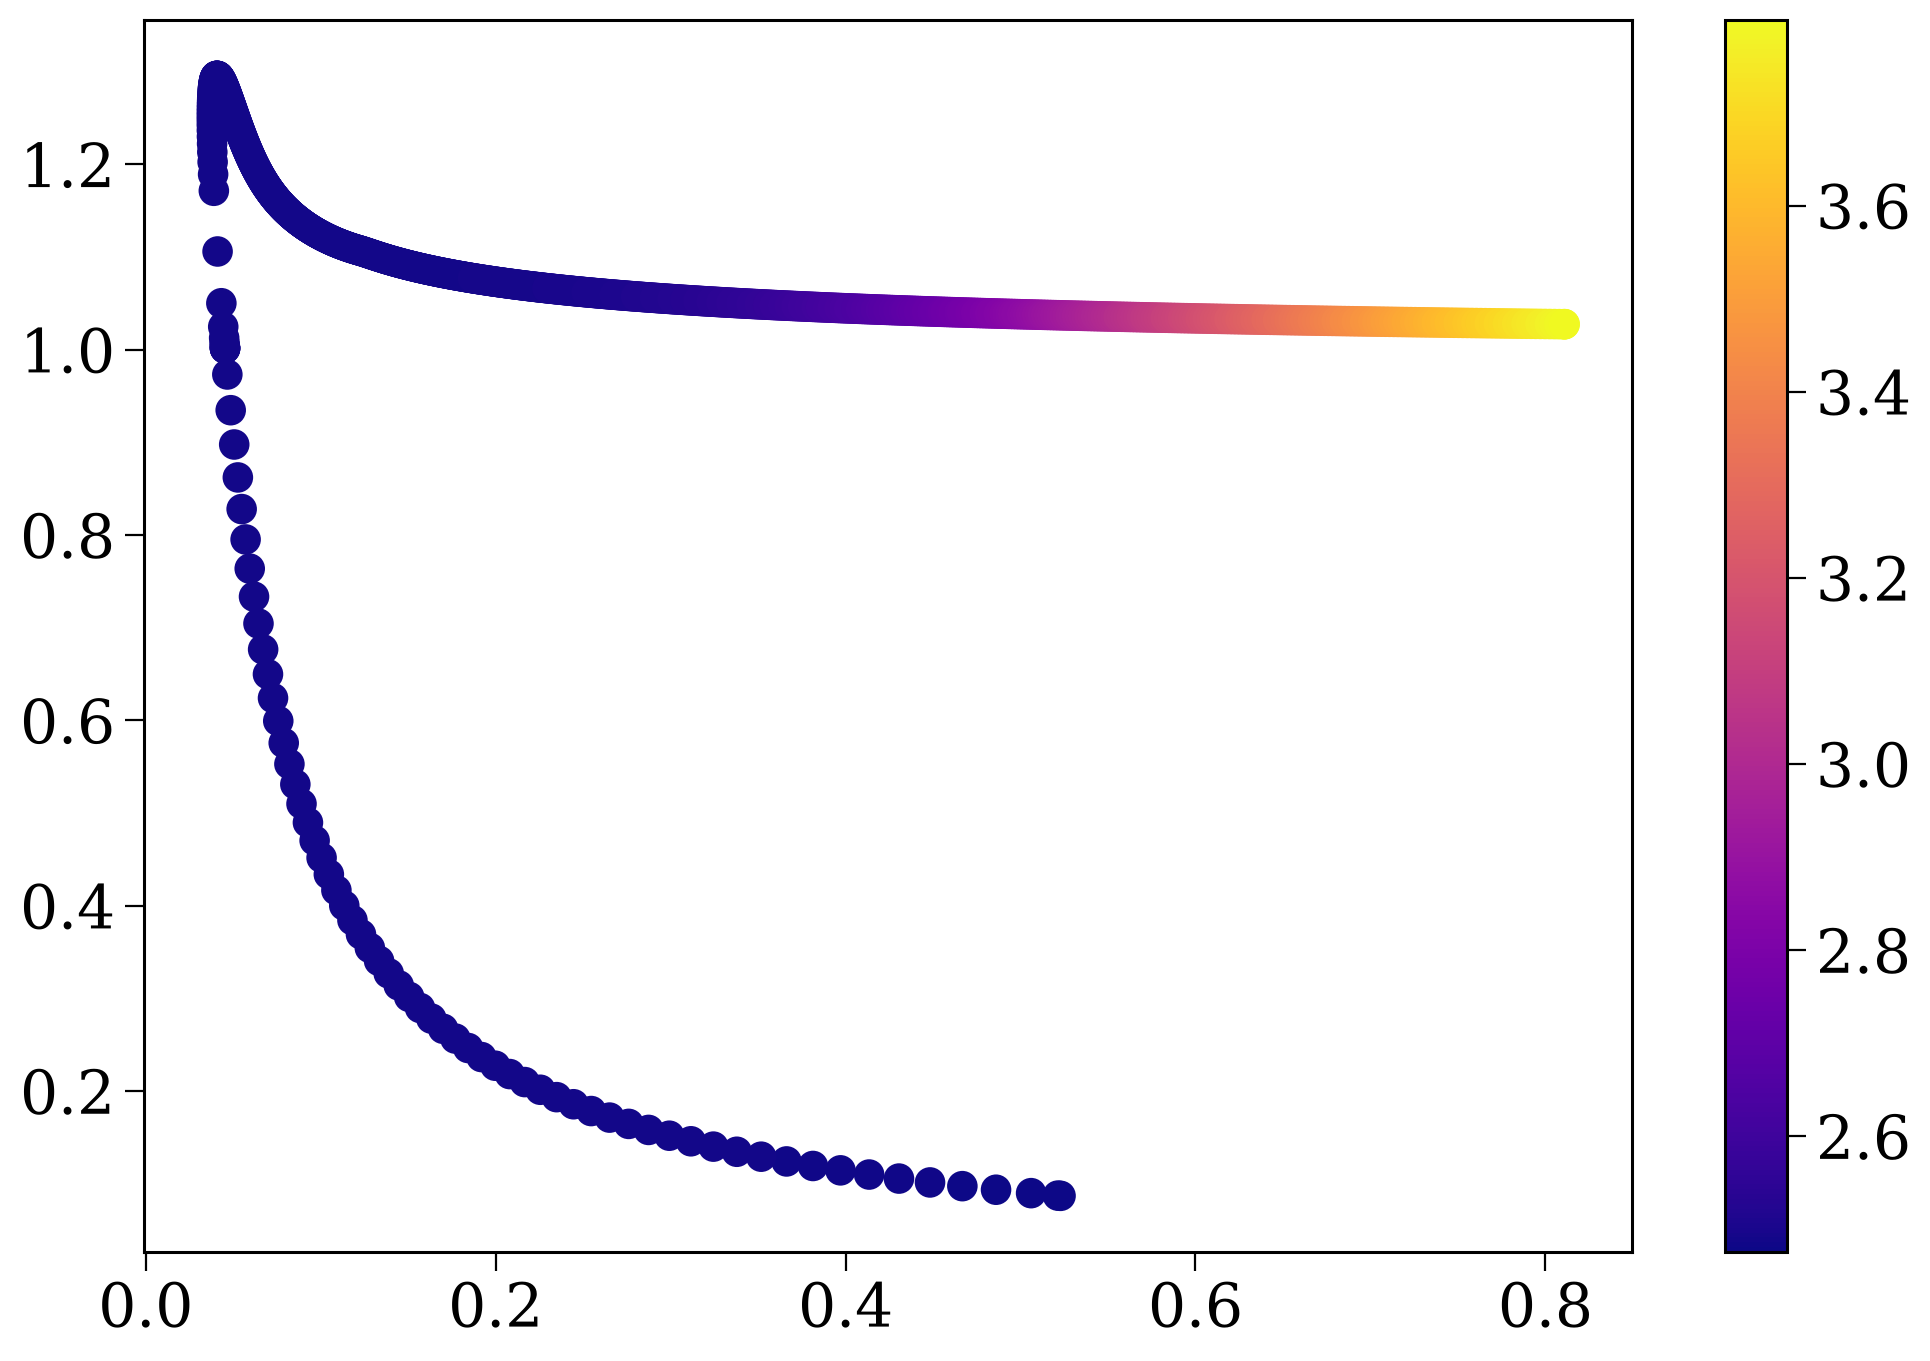

In [147]:
scatter = plt.scatter(ex_bcm["sep"].loc[EX], ex_bcm["RRLO_2"].loc[EX], c=np.log10(ex_bcm["tphys"].loc[EX]), cmap="plasma", s=100)
plt.colorbar(scatter)

In [167]:
bpp.loc[EX][["tphys", "mass_1", "mass_2", "porb", "ecc", "kstar_1", "kstar_2", "sep", "evol_type"]]

,tphys,mass_1,mass_2,porb,ecc,kstar_1,kstar_2,sep,evol_type
5045,0.000000,9.860070,1.916214,1685.680756,0.360556,1,1,1355.620720,1
5045,25.745984,9.694610,1.916215,1734.060431,0.360556,2,1,1374.935785,2
5045,25.815740,9.692440,1.916218,1734.587891,0.360524,3,1,1375.128989,2
5045,25.825488,9.690969,1.916229,1680.266746,0.347134,4,1,1346.211103,2
5045,28.778905,9.352731,1.918051,1413.392138,0.018437,5,1,1187.895854,2
5045,28.857940,9.304434,1.918824,1102.613908,0.000000,5,1,1005.249467,3
5045,28.857940,9.304434,1.918824,1102.613908,0.000000,5,1,1005.249467,7
5045,28.857940,2.839275,1.918824,5.678438,0.000000,8,1,22.520722,8
5045,28.857940,2.839275,1.918824,5.678438,0.000000,8,1,22.520722,4
5045,28.896840,2.819315,1.920012,5.712751,0.000000,8,1,22.581580,3


In [168]:
ex_bpp.loc[EX][["tphys", "mass_1", "mass_2", "porb", "ecc", "kstar_1", "kstar_2", "sep", "evol_type"]]

,tphys,mass_1,mass_2,porb,ecc,kstar_1,kstar_2,sep,evol_type
5045,1302.667011,1.277595,0.234532,0.002200,0.0,13,10,0.081673,3
5045,13700.000000,1.413235,0.005889,0.084554,0.0,13,10,0.910711,10


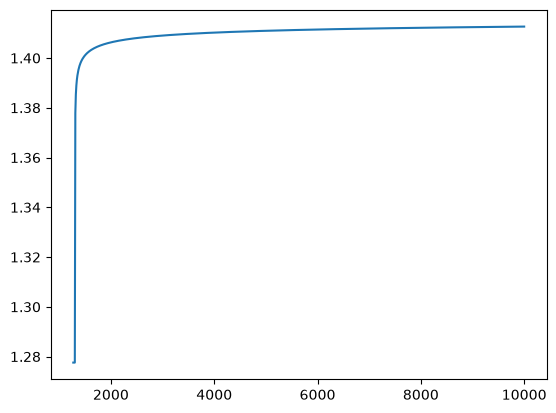

In [169]:
from scipy.interpolate import interp1d

t_range = np.linspace(0, 1e4, 1000)
mass_int = interp1d(ex_bcm.loc[EX]["tphys"], ex_bcm.loc[EX]["mass_1"], fill_value=np.nan, bounds_error=False)
plt.plot(t_range, mass_int(t_range))

In [156]:
ex_bcm.loc[EX][["tphys", "mass_1", "mass_2", "porb", "ecc", "kstar_1", "kstar_2", "sep"]]

,tphys,mass_1,mass_2,porb,ecc,kstar_1,kstar_2,sep
5045,1267.598890,1.277595,0.234532,0.039567,0.0,13,10,0.560662
5045,1267.698890,1.277595,0.234532,0.039521,0.0,13,10,0.560234
5045,1268.698890,1.277595,0.234532,0.039070,0.0,13,10,0.555957
5045,1273.770558,1.277595,0.234532,0.036772,0.0,13,10,0.533942
5045,1278.085346,1.277595,0.234532,0.034610,0.0,13,10,0.512797
...,...,...,...,...,...,...,...,...
5045,13112.967006,1.413157,0.005967,0.083446,0.0,13,10,0.902740
5045,13333.343747,1.413187,0.005937,0.083867,0.0,13,10,0.905775
5045,13557.826563,1.413216,0.005907,0.084291,0.0,13,10,0.908820
5045,13700.000000,1.413235,0.005889,0.084554,0.0,13,10,0.910711


In [32]:
ex_bcm.loc[EX]["RRLO_2"]

18671    0.024906
18671    0.024906
18671    0.024911
18671    0.024960
18671    0.025465
           ...   
18671    1.025356
18671    1.025299
18671    1.025241
18671    1.025190
18671    1.025190
Name: RRLO_2, Length: 1004, dtype: float64

In [130]:
ex_bcm.loc[527]

,tphys,kstar_1,mass0_1,mass_1,lum_1,rad_1,teff_1,massc_he_layer_1,massc_co_layer_1,radc_1,...,porb,sep,ecc,B_1,B_2,SN_1,SN_2,bin_state,merger_type,bin_num
527,298.947274,13,8.539961,1.329429,2.708298e-07,0.000014,35349.208337,0.0,0.0,0.000014,...,0.032126,0.522877,0.0,0.0,0.0,0,0,0,-001,527
527,299.047274,13,8.539961,1.329429,2.706487e-07,0.000014,35343.297538,0.0,0.0,0.000014,...,0.031986,0.521350,0.0,0.0,0.0,0,0,0,-001,527
527,300.047274,13,8.539961,1.329429,2.688476e-07,0.000014,35284.352169,0.0,0.0,0.000014,...,0.030588,0.506050,0.0,0.0,0.0,0,0,0,-001,527
527,301.248244,13,8.539961,1.329429,2.667083e-07,0.000014,35213.948816,0.0,0.0,0.000014,...,0.028789,0.486010,0.0,0.0,0.0,0,0,0,-001,527
527,302.269985,13,8.539961,1.329429,2.649083e-07,0.000014,35154.382876,0.0,0.0,0.000014,...,0.027096,0.466764,0.0,0.0,0.0,0,0,0,-001,527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
527,6075.248469,13,8.539961,1.462408,6.990332e-10,0.000014,7967.646310,0.0,0.0,0.000014,...,0.069080,0.805227,0.0,0.0,0.0,0,0,0,-001,527
527,6183.011135,13,8.539961,1.462444,6.748900e-10,0.000014,7897.940266,0.0,0.0,0.000014,...,0.069429,0.807937,0.0,0.0,0.0,0,0,0,-001,527
527,6292.783736,13,8.539961,1.462480,6.515602e-10,0.000014,7828.782657,0.0,0.0,0.000014,...,0.069779,0.810656,0.0,0.0,0.0,0,0,0,-001,527
527,6304.553358,13,8.539961,1.462483,6.491309e-10,0.000014,7821.475040,0.0,0.0,0.000014,...,0.069816,0.810939,0.0,0.0,0.0,0,0,0,-001,527


In [125]:
ex_source.snr.max()

np.float64(531.378677769391)

/tmp/ipykernel_438288/3277121422.py:24: RuntimeWarning: invalid value encountered in scalar power
  values[mask2] = A * b**(a1 - a2) * t[mask2]**a2


17.238285583236202 393.0924368122555
26.617293744841835 138.29186248437225
17.803227054988508 171.48582877200644
17.69535381808351 417.7725037605767
19.355118761406324 531.378677769391


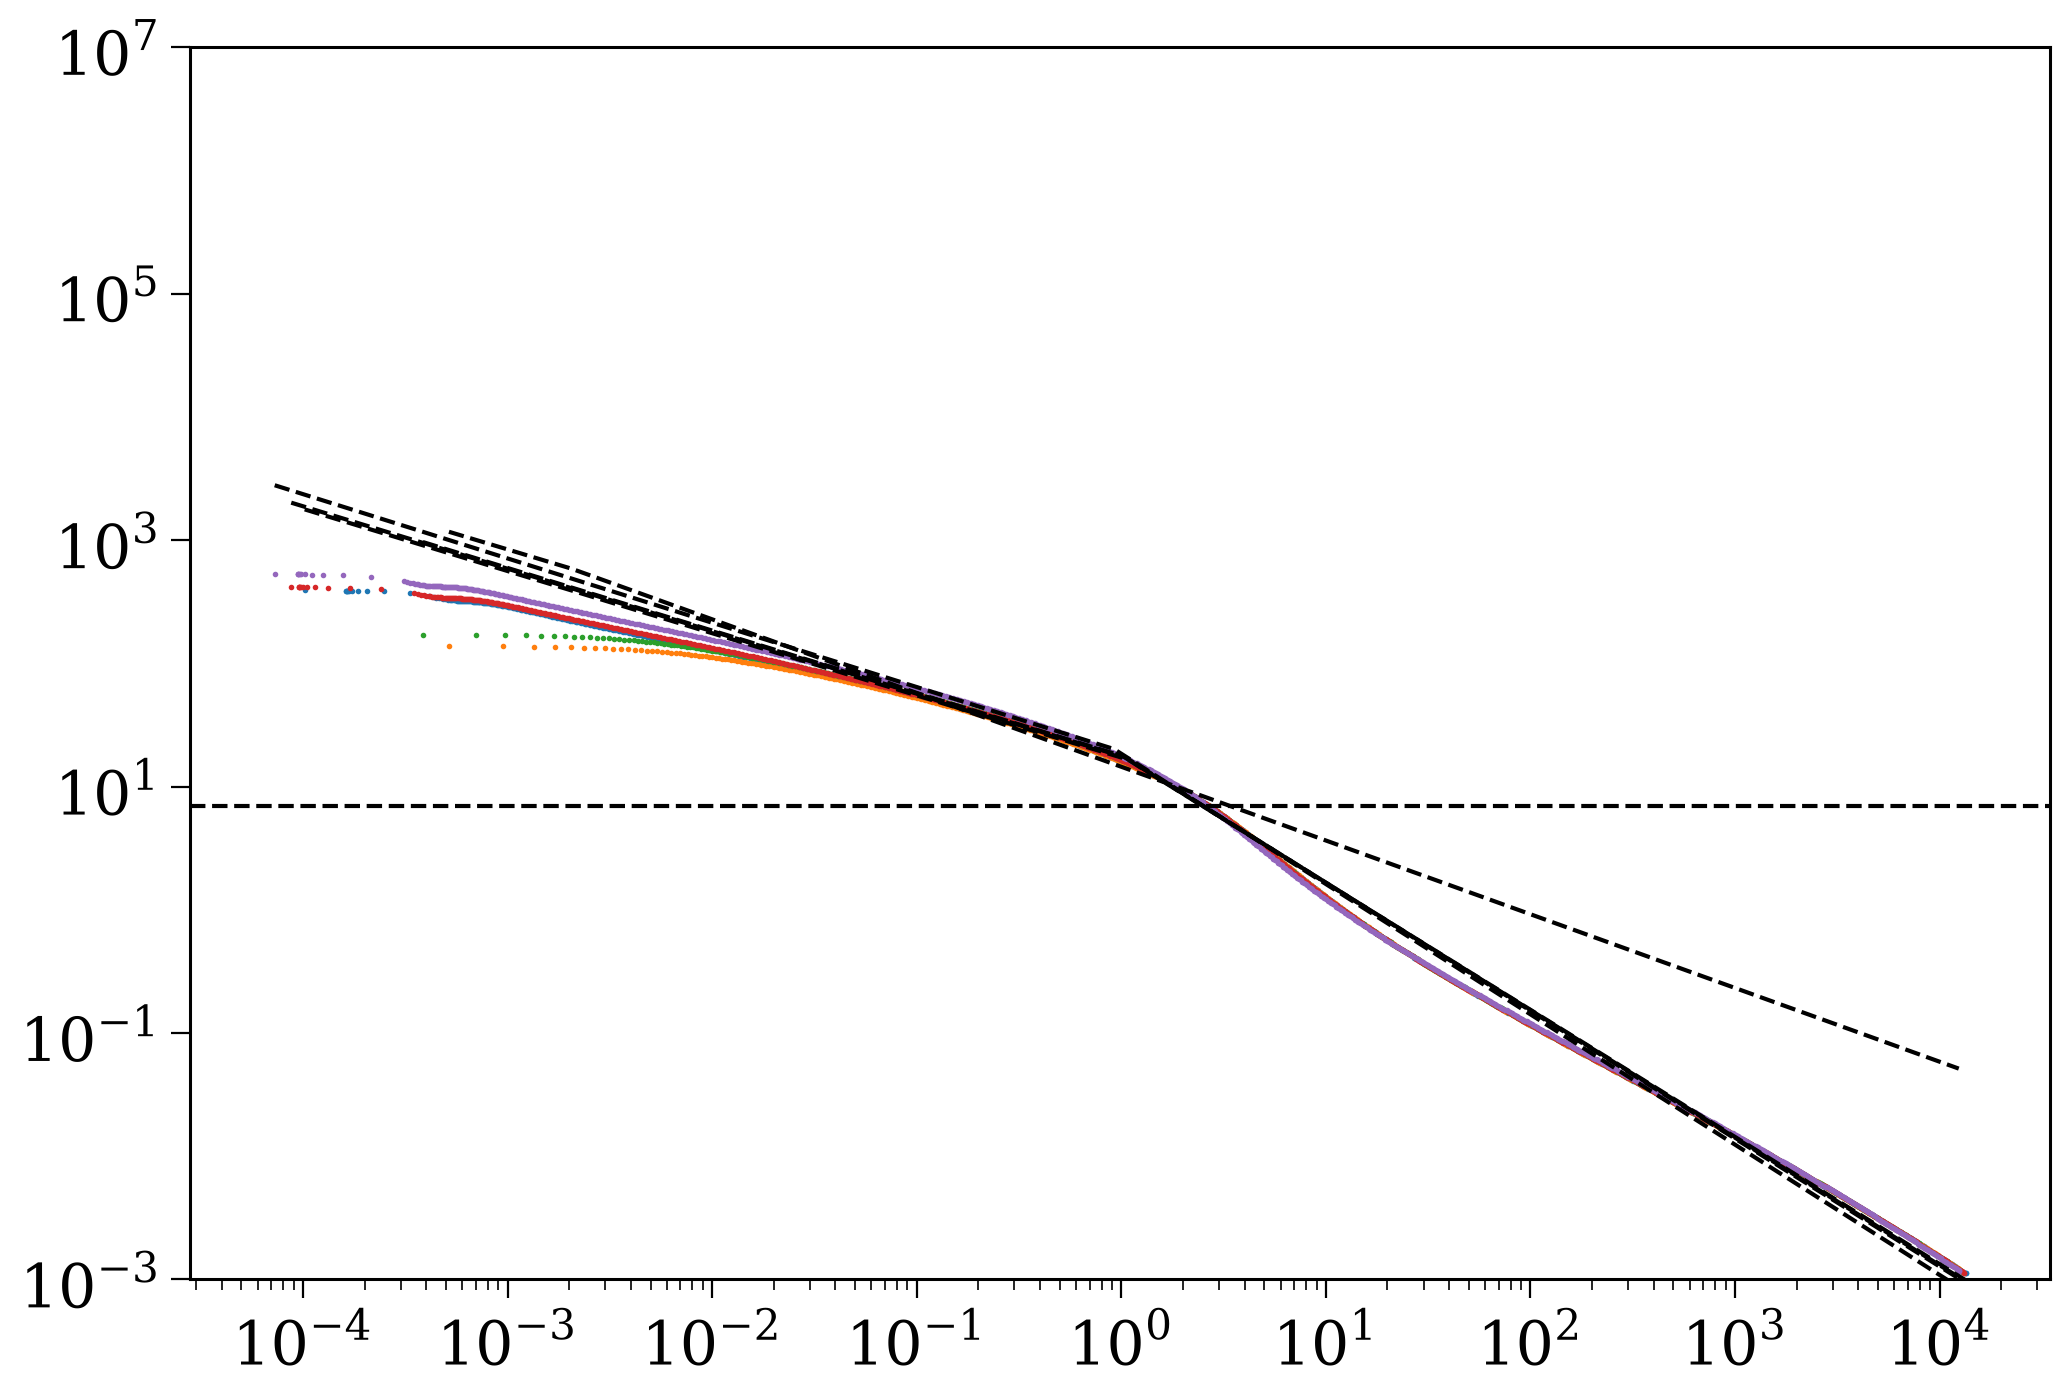

In [ ]:
def model(t, A, alpha):
    return A * t**alpha

def model_two_part_broken_power_law(t, A, a1, a2, b):
    """
    Two-part broken power law model.
    
    Parameters:
    - t: Time (independent variable)
    - A: Normalization constant
    - a1, a2: Power-law indices for the two segments
    - b: Break point (in time) where the power-law index changes
    
    Returns:
    - Model values corresponding to the input time t.
    """
    values = np.zeros_like(t)
    # First segment: t < b
    mask1 = t < b
    values[mask1] = A * t[mask1]**a1

    # Second segment: t >= b
    mask2 = t >= b
    values[mask2] = A * b**(a1 - a2) * t[mask2]**a2

    return values

def model_three_part_broken_power_law(t, A, a1, a2, a3, b1, b2):
    """
    Three-part broken power law model.
    
    Parameters:
    - t: Time (independent variable)
    - A: Normalization constant
    - a1, a2, a3: Power-law indices for the three segments
    - b1, b2: Break points (in time) where the power-law indices change
    
    Returns:
    - Model values corresponding to the input time t.
    """
    values = np.zeros_like(t)
    # First segment: t < b1
    mask1 = t < b1
    values[mask1] = A * t[mask1]**a1

    # Second segment: b1 <= t < b2
    mask2 = (t >= b1) & (t < b2)
    values[mask2] = A * b1**(a1 - a2) * t[mask2]**a2

    # Third segment: t >= b2
    mask3 = t >= b2
    values[mask3] = A * b1**(a1 - a2) * b2**(a2 - a3) * t[mask3]**a3

    return values

from scipy.optimize import curve_fit

for EX in examples[:5]:
    ex_source = bpp_to_source(ex_bcm.loc[EX], dist=10 * u.kpc, interpolate_g=False)
    ex_source.get_snr()

    peak_snr_ind = np.nanargmax(ex_source.snr)
    peak_time = ex_bcm.loc[EX]["tphys"].values[peak_snr_ind]
    norm_t = ex_bcm.loc[EX]["tphys"] - peak_time

    factors = [0.5, 0.1, 0.01]
    for factor in factors:
        # find the time at which the SNR drops to a fraction of the peak SNR

    min_t = 1e-1

    # fit the model to the data
    # popt, pcov = curve_fit (model_three_part_broken_power_law, norm_t[norm_t > min_t], ex_source.snr[norm_t > min_t], p0=[1e4, -0.5, -0.5, -0.5, 1, 10])
    popt, pcov = curve_fit(model_two_part_broken_power_law, norm_t[norm_t > min_t], ex_source.snr[norm_t > min_t], p0=[1e4, -0.5, -0.5, 1])
    print(popt[0], ex_source.snr[peak_snr_ind])


    plt.scatter(norm_t, ex_source.snr, s=1)
    plt.plot(norm_t[norm_t > 0], model_two_part_broken_power_law(norm_t[norm_t > 0], *popt), c="k", ls="--", label=f"fit: A={popt[0]:.2e}, alpha={popt[1]:.2f}")

plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-3, 1e7)
plt.axhline(7, c="k", ls="--")

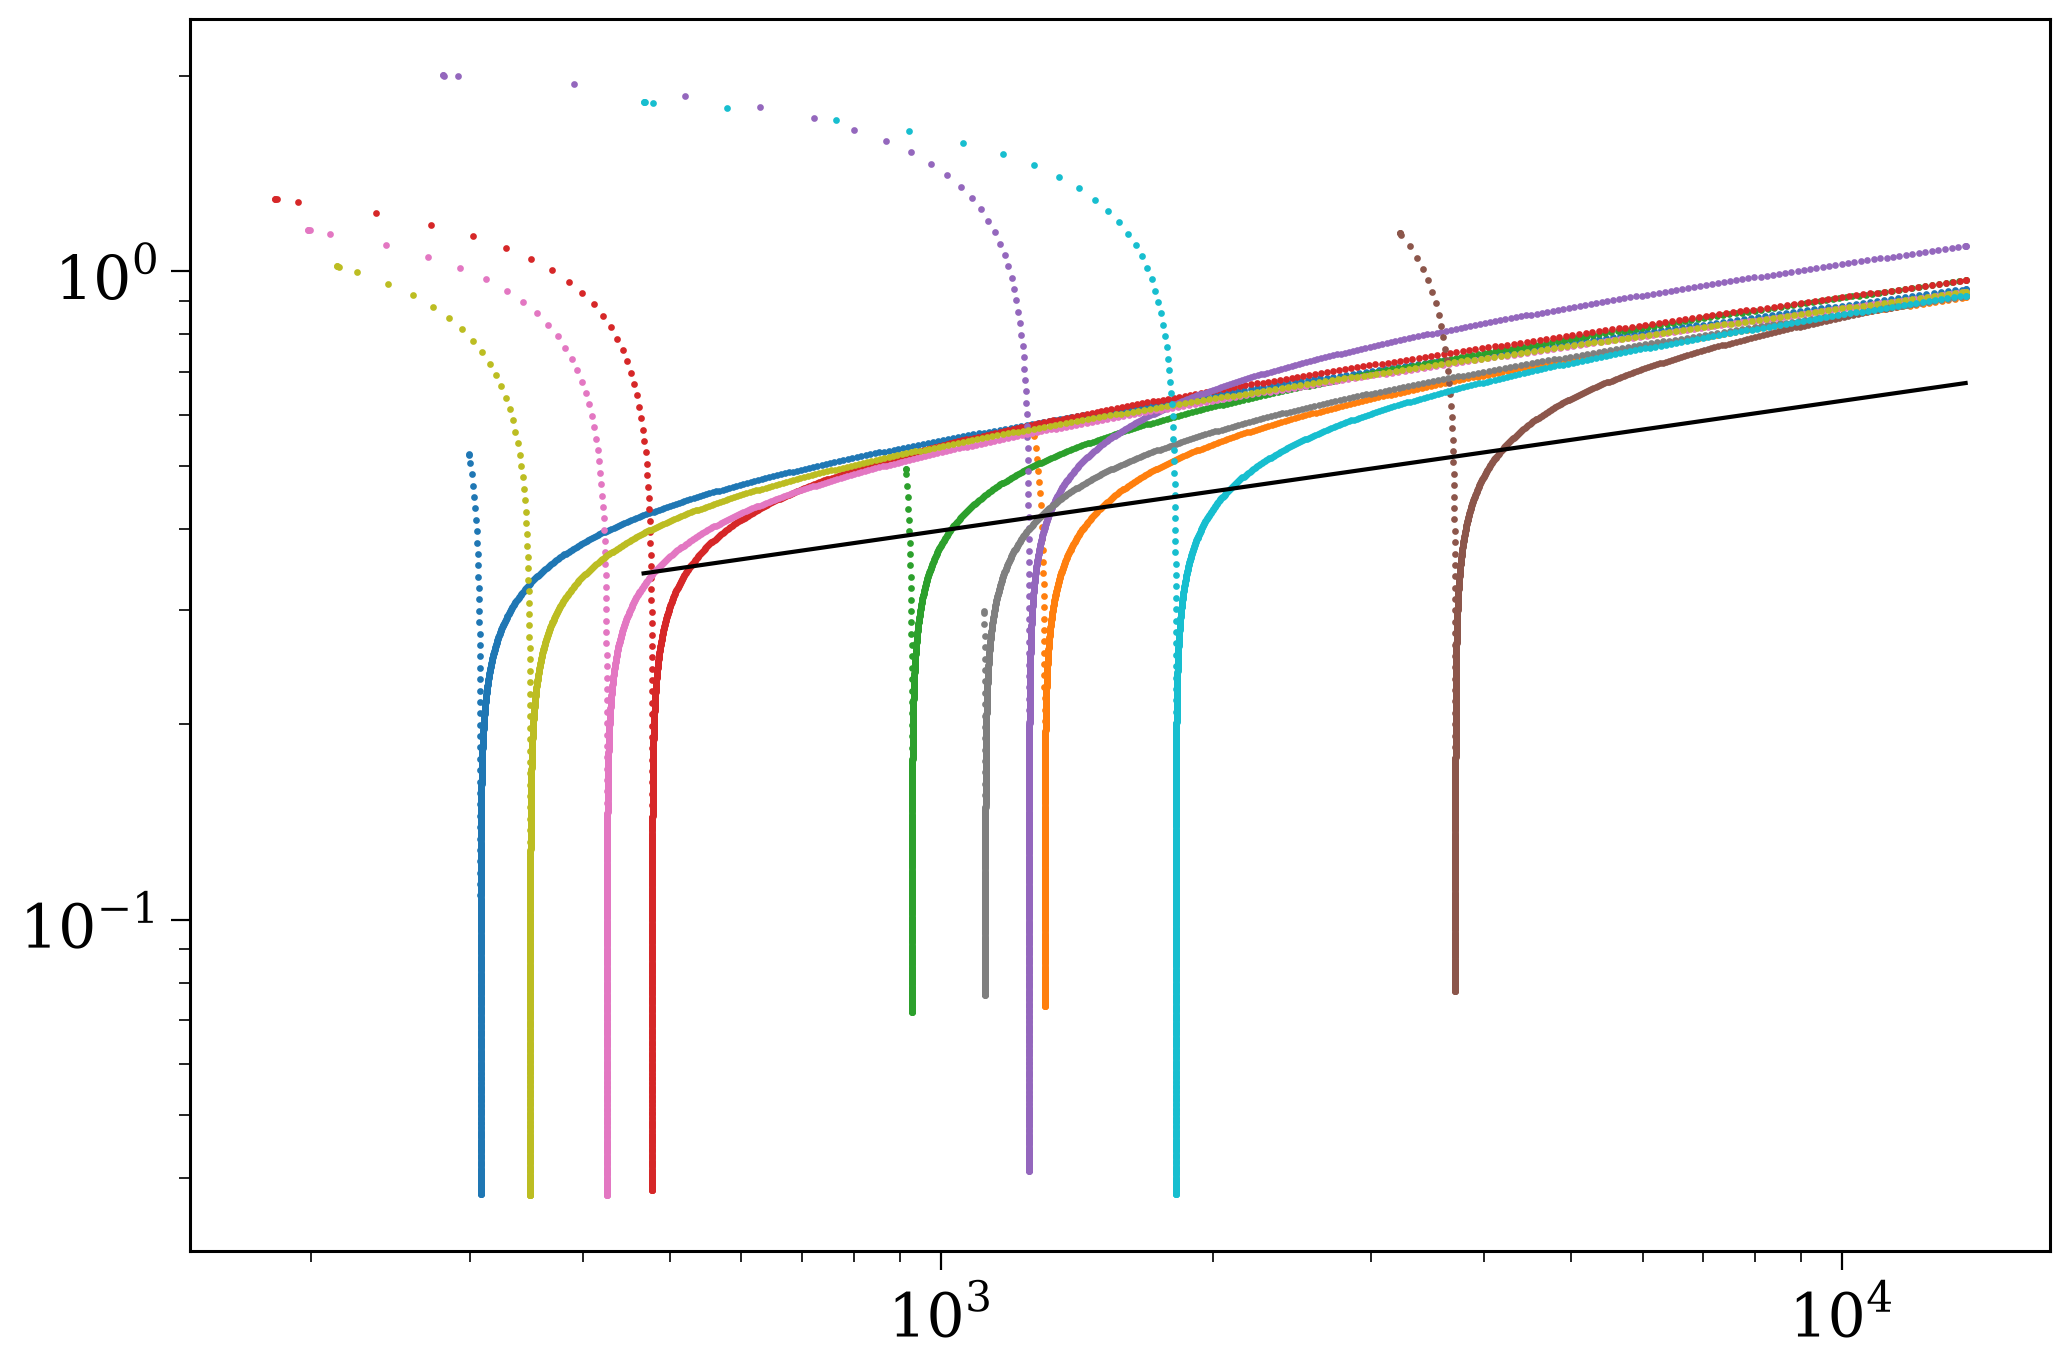

In [119]:
for EX in examples[:10]:
    # ex_source = bpp_to_source(ex_bcm.loc[EX], dist=10 * u.kpc, interpolate_g=False)
    # ex_source.get_snr()

    peak_snr_ind = np.nanargmax(ex_source.snr)
    peak_time = ex_bcm.loc[EX]["tphys"].values[peak_snr_ind]
    norm_t = ex_bcm.loc[EX]["tphys"] - peak_time

    min_t = 1e-1

    plt.scatter(ex_bcm.loc[EX]["tphys"], ex_bcm["sep"].loc[EX], s=2)

plt.loglog(ex_bcm.loc[EX]["tphys"], 1e-1 *ex_bcm.loc[EX]["tphys"] **0.2, c='k')

plt.yscale("log")
plt.xscale("log")
# plt.ylim(1e-3, 1e7)
# plt.axhline(7, c="k", ls="--")

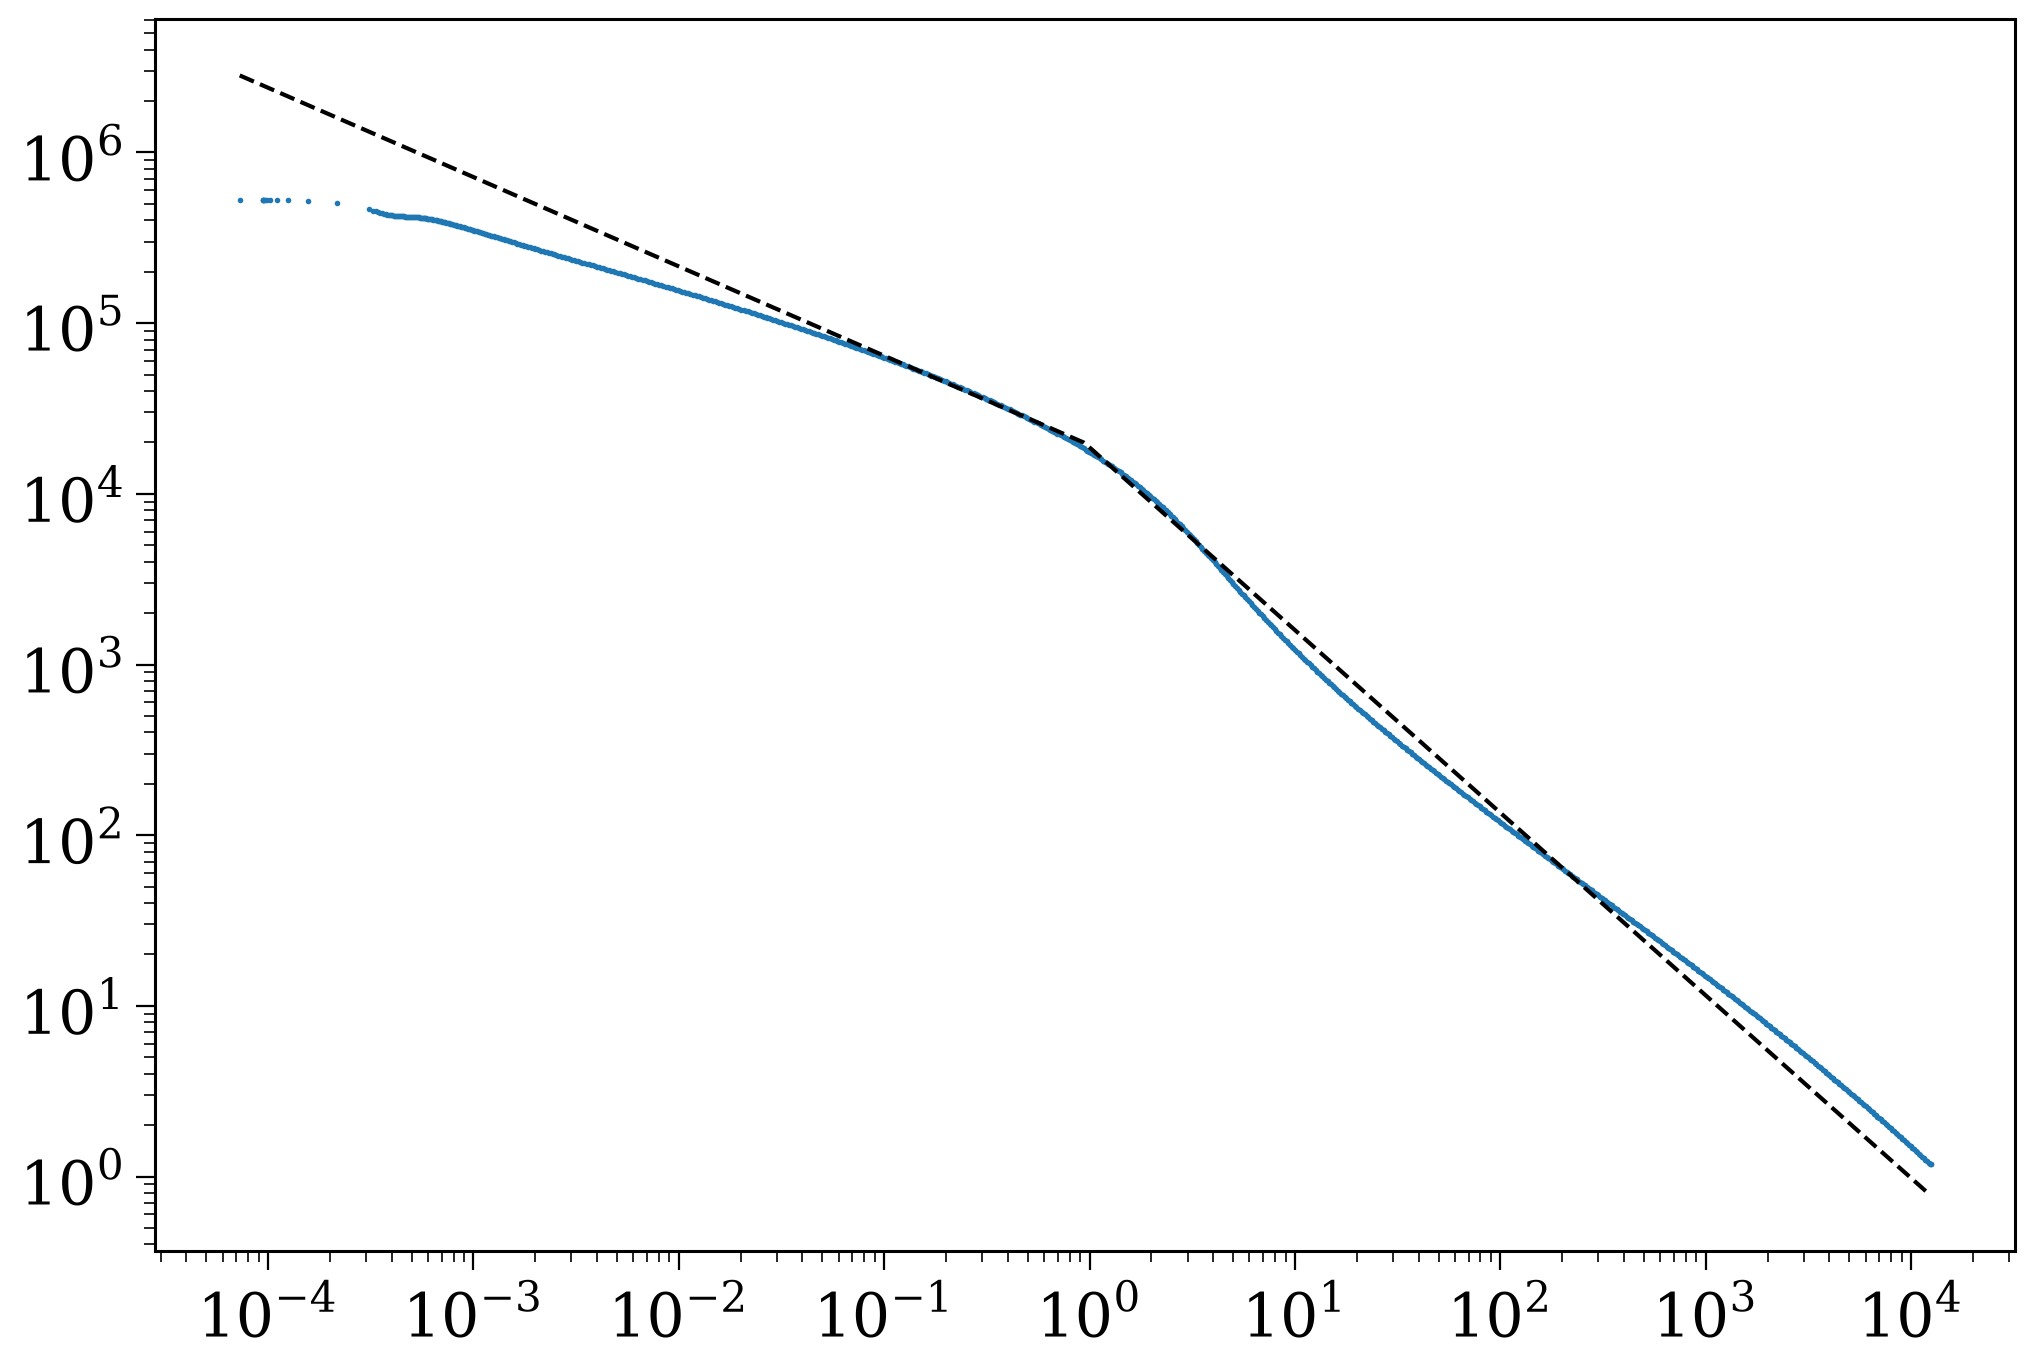

In [100]:
plt.scatter(norm_t, ex_source.snr, s=1)
plt.loglog(norm_t[norm_t > 0], model_two_part_broken_power_law(norm_t[norm_t > 0], *popt), c="k", ls="--", label=f"fit: A={popt[0]:.2e}, alpha={popt[1]:.2f}")


In [58]:
popt

array([ 7.56798308e+03, -9.05566346e-01])

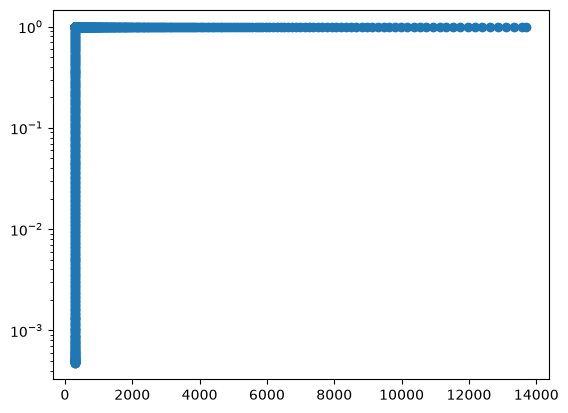

In [19]:
plt.scatter(ex_bcm.loc[EX]["tphys"], 1 - ((ex_bcm.loc[EX]["mass_2"].diff() + ex_bcm.loc[EX]["mass_1"].diff()) / ex_bcm.loc[EX]["mass_2"].diff()))
plt.yscale("log")

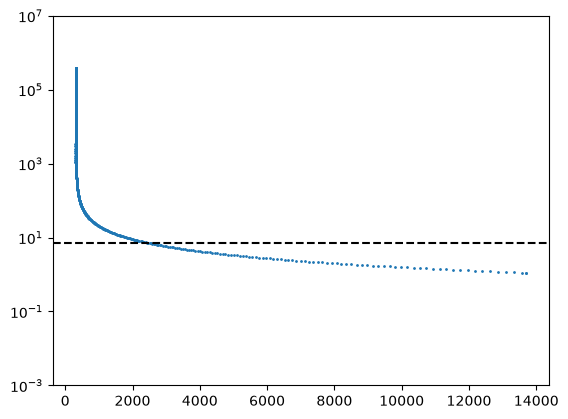

In [34]:
ex_bcm.loc[8024]

,tphys,kstar_1,mass0_1,mass_1,lum_1,rad_1,teff_1,massc_he_layer_1,massc_co_layer_1,radc_1,...,porb,sep,ecc,B_1,B_2,SN_1,SN_2,bin_state,merger_type,bin_num
8024,0.000000,1,21.323784,21.323784,4.957368e+04,5.978024,35383.727035,0.0,0.0,0.000000,...,3019.017436,2572.779675,0.000016,0.000000e+00,0.0,0,0,0,-001,8024
8024,0.008368,1,21.323490,21.323490,4.959804e+04,5.981144,35378.841458,0.0,0.0,0.000000,...,3019.088324,2572.809879,0.000016,0.000000e+00,0.0,0,0,0,-001,8024
8024,0.016736,1,21.323195,21.323195,4.962245e+04,5.984266,35373.963497,0.0,0.0,0.000000,...,3019.159273,2572.840110,0.000016,0.000000e+00,0.0,0,0,0,-001,8024
8024,0.025104,1,21.322900,21.322900,4.964691e+04,5.987389,35369.093111,0.0,0.0,0.000000,...,3019.230283,2572.870366,0.000016,0.000000e+00,0.0,0,0,0,-001,8024
8024,0.033472,1,21.322605,21.322605,4.967142e+04,5.990514,35364.230258,0.0,0.0,0.000000,...,3019.301354,2572.900647,0.000016,0.000000e+00,0.0,0,0,0,-001,8024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8024,13246.374977,13,5.723890,2.114405,1.885258e-10,0.000014,5741.802978,0.0,0.0,0.000014,...,0.087269,1.063266,0.000000,5.166356e+07,0.0,1,0,0,-001,8024
8024,13445.850298,13,5.723890,2.114433,1.829711e-10,0.000014,5699.033392,0.0,0.0,0.000014,...,0.087711,1.066853,0.000000,5.166320e+07,0.0,1,0,0,-001,8024
8024,13649.052807,13,5.723890,2.114461,1.775612e-10,0.000014,5656.432804,0.0,0.0,0.000014,...,0.088155,1.070452,0.000000,5.166283e+07,0.0,1,0,0,-001,8024
8024,13700.000000,13,5.723890,2.114468,1.762425e-10,0.000014,5645.900864,0.0,0.0,0.000014,...,0.088265,1.071337,0.000000,5.166247e+07,0.0,1,0,0,-001,8024


In [5]:
s = bpp_to_source(post_dco_rlof_rows, dist=10 * u.pc, n_proc=20)
s.get_snr()
print(s.snr)

[390189.39799841 127959.65368984 158814.00667364 ... 392757.02806737
 420237.59097615 199035.95828244]


In [9]:
formation_rows

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,...,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
527,298.947274,1.329429,0.531034,13,11,0.522877,0.032126,0.0,5.820684e-05,0.086827,...,0.0,0.051853,0.0,225.286434,0.0,37.656428,298.947274,0.0,0.0,527
5045,1267.598890,1.277595,0.234532,13,10,0.560662,0.039567,0.0,2.051345e-06,0.002445,...,0.0,0.000012,0.0,24.279225,0.0,28.902842,0.012811,0.0,0.0,5045
5143,912.830019,1.463924,0.252634,13,10,0.495442,0.030848,0.0,3.231965e-06,0.003972,...,0.0,0.148736,0.0,7.137671,0.0,19.571541,-13.542533,0.0,0.0,5143
5539,182.094280,1.441435,0.531034,13,11,1.290760,0.121014,0.0,2.321616e-05,0.035919,...,0.0,0.025397,0.0,159.882189,0.0,17.746312,182.094280,0.0,0.0,5539
8024,279.728255,1.988167,0.531034,13,11,2.002759,0.206959,0.0,1.410470e-05,0.025208,...,0.0,0.002904,0.0,239.952416,0.0,10.043944,279.728255,0.0,0.0,8024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999789,31.113715,1.288023,0.647444,13,11,0.419200,0.022611,0.0,1.902109e-05,0.990000,...,0.0,0.010469,0.0,4.124874,0.0,26.991663,26.676287,0.0,0.0,1999789
1999803,32.963081,1.288013,0.647217,13,11,0.395204,0.020698,0.0,1.961037e-05,0.990000,...,0.0,0.010451,0.0,4.075711,0.0,28.889629,28.496242,0.0,0.0,1999803
1999817,33.407339,1.287060,0.642511,13,11,0.435340,0.023965,0.0,1.895462e-05,0.990000,...,0.0,0.009477,0.0,4.924601,0.0,28.482900,28.183948,0.0,0.0,1999817
1999851,166.454491,1.465178,0.531034,13,11,1.482497,0.148067,0.0,2.015092e-05,0.031407,...,0.0,0.031867,0.0,147.050314,0.0,17.462036,166.454491,0.0,0.0,1999851


In [23]:
final_rows["RRLO_2"]

527        1.024855
5045       1.024956
5143       1.025331
5539       1.025671
8024       1.026911
             ...   
1999789    1.024702
1999803    1.024710
1999817    1.024687
1999851    1.026379
1999886    1.030734
Name: RRLO_2, Length: 20737, dtype: float64

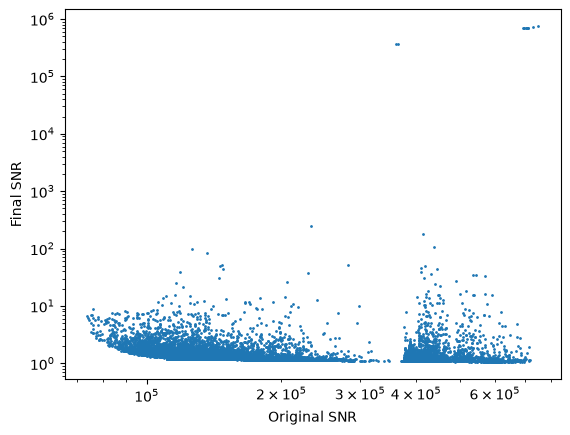

In [18]:
import matplotlib.pyplot as plt
plt.scatter(s.snr, final_s[np.isin(final_rows["bin_num"], post_dco_rlof_rows["bin_num"])].snr, s=1)
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Original SNR")
plt.ylabel("Final SNR")
plt.show()

In [10]:
final_s = bpp_to_source(final_rows, dist=10 * u.pc, n_proc=20)
final_s.get_snr()

array([1.11217466, 1.2160271 , 1.16821606, ..., 1.09378917, 1.65462545,
       4.98319023], shape=(20737,))

In [11]:
final_s

<Source: 20737 sources>

In [18]:
(final_s.snr > 7).sum()

np.int64(184)

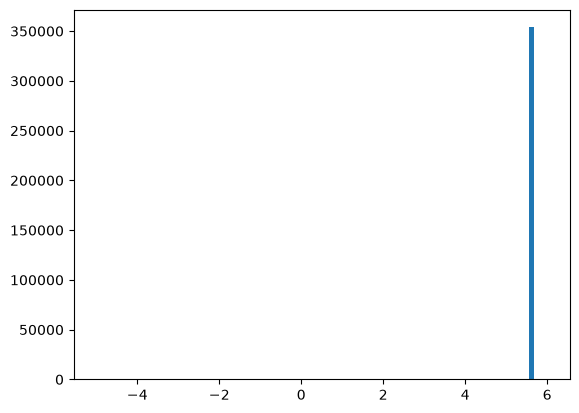

In [7]:
import matplotlib.pyplot as plt
plt.hist(np.log10(s.snr), bins=100, range=(-5, 6));
# plt.hist(np.log10(final_s.snr), bins=100, range=(-5, 6));

In [31]:
final_s.snr

array([1.19243986e-03, 1.25842935e+02, 1.10437277e-03, ...,
       1.33187152e+02, 1.58161906e+02, 1.18560257e+02], shape=(58340,))

[1596.76395864 3347.68219038 2307.09240216 ... 3359.21484811 3155.84992504
 3162.57455594]


In [22]:
bpp.loc[bpp.index.unique()[10], ["tphys", "mass_1", "mass_2", "kstar_1", "kstar_2", "sep", "ecc", "RRLO_1", "RRLO_2", "evol_type"]]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,RRLO_1,RRLO_2,evol_type
18454,0.000000,23.177071,8.375171,1,1,2362.397983,0.081438,0.004456,0.003787,1
18454,8.402975,23.002444,8.374934,2,1,2375.561747,0.081438,0.010503,0.004174,2
18454,8.416784,23.001690,8.374934,4,1,2375.618813,0.081438,0.029896,0.004174,2
18454,9.229089,22.782056,8.377147,5,1,2369.270390,0.078161,0.631618,0.004207,2
18454,9.244814,22.749493,8.378249,5,1,2284.795077,0.050116,0.631618,0.004207,15
18454,9.244814,12.065605,8.378249,14,1,1226.234211,0.974574,0.000004,0.251327,2
18454,33.698361,12.065609,8.375910,14,2,1226.079480,0.974573,0.000004,0.481980,2
18454,33.731685,12.065609,8.375893,14,2,31.175170,0.000000,0.000004,1.000999,3
18454,33.787890,12.279948,7.100260,14,2,37.871613,0.000000,0.000003,3.012363,5
18454,33.787890,12.279948,7.100260,14,2,37.871613,0.000000,0.000003,3.012363,7


<Axes: >

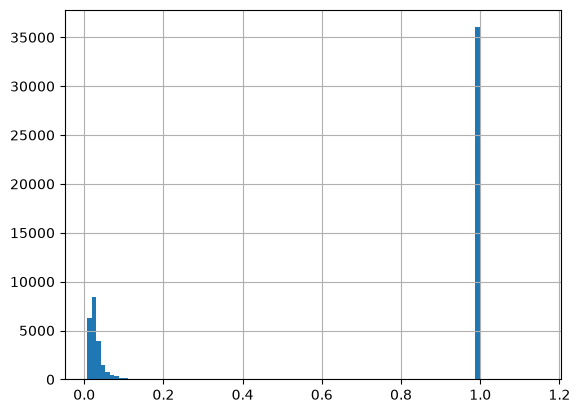

In [5]:
formation_rows["RRLO_2"].hist(bins=100)

In [13]:
(formation_rows["RRLO_2"] >= 0.99).sum()

np.int64(36020)

In [8]:
lw.source.Source(
    m_1=1.327648 * u.Msun, m_2=0.192416 * u.Msun, ecc=0, a=0.002722 * u.Rsun, dist=8 * u.kpc, interpolate_g=False
).get_snr()

array([2.59017601])

In [2]:
DCO_TYPES = ["NSWD", "NSNS", "BHWD", "BHNS", "BHBH"]
kstar_masks = [([13], [10, 11, 12]), ([13], [13]), ([14], [10, 11, 12]), ([14], [13]), ([14], [14])]
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"

In [ ]:
for kstars, dco_type in zip(kstar_masks, DCO_TYPES):
    if dco_type != "BHBH":
        continue
    print(f"Processing {dco_type}...")
    all_formation_rows = None
    for file in os.listdir(FOLDER):
        if file.startswith(f"{dco_type}_Z_"):
            print(f"  Adding file: {file}")
            initC = cosmic.output.load_initC(f"{FOLDER}/{file}", key="initC")
            bpp = pd.read_hdf(f"{FOLDER}/{file}", key="bpp")
            k_lo, k_hi = kstars
            mask = ((
                (bpp["kstar_1"].isin(k_lo)) & (bpp["kstar_2"].isin(k_hi))
            ) | (
                (bpp["kstar_1"].isin(k_hi)) & (bpp["kstar_2"].isin(k_lo))
            )) & (bpp["sep"] > 0)
            if mask.sum() == 0:
                print(f"    No {dco_type} systems found in this file.")
                continue
            formation_rows = bpp[mask].drop_duplicates(subset="bin_num")[["tphys", "mass_1", "mass_2", "kstar_1", "kstar_2", "sep", "ecc", "bin_num"]]
            formation_rows["metallicity"] = initC["metallicity"].iloc[0]

            with h5.File(f"{FOLDER}/{file}", "r") as f:
                formation_rows["weights"] = f["stroopwafel"]["weights"][...][f["stroopwafel"]["is_hit"][...]]

            if all_formation_rows is None:
                all_formation_rows = formation_rows
            else:
                all_formation_rows = pd.concat([all_formation_rows, formation_rows], ignore_index=True)
    # all_formation_rows.to_hdf(f"{FOLDER}/{dco_type}_formation_rows.h5", key="formation_rows", mode="w")

Processing BHBH...


In [5]:
file

'NSWD_pessimistic_detectable_sources.h5'

In [8]:
dco_type = "BHBH"
kick_infos = [pd.read_hdf(f"{FOLDER}/{file}", key="kick_info")[
    ["tphys", "star", "delta_vsysx_1", "delta_vsysy_1", "delta_vsysz_1", "bin_num"]
] for file in os.listdir(FOLDER) if file.startswith(f"{dco_type}_Z_")]

In [9]:
all_kick_infos = pd.concat(kick_infos, ignore_index=True)
all_kick_infos.index = all_kick_infos.index.values // 2

In [10]:
all_kick_infos.to_hdf(f"{FOLDER}/{dco_type}_kick_info.h5", key="kick_info", mode="w")

In [58]:
all_formation_rows = pd.read_hdf(f"{FOLDER}/{dco_type}_formation_rows.h5", key="formation_rows")

In [84]:
N = 10_000_0000
s = lw.source.Source(
    m_1=all_formation_rows["mass_1"].values[:N] * u.Msun,
    m_2=all_formation_rows["mass_2"].values[:N] * u.Msun,
    ecc=all_formation_rows["ecc"].values[:N] * u.dimensionless_unscaled,
    a=all_formation_rows["sep"].values[:N] * u.Rsun,
    dist=np.full(len(all_formation_rows), 8)[:N] * u.kpc,
    interpolate_g=False,
    n_proc=28
)

In [85]:
merger_times = s.get_merger_time(exact=False)

In [86]:
merger_times

<Quantity [0.92064125, 0.14068622, 2.89982714, ..., 7.37982187, 0.02091155,
           0.73508567] Gyr>

In [87]:
s.m_1

<Quantity [ 9.00852903,  3.85121529, 23.17378805, ...,  7.16966588,
            6.0047431 , 11.3130957 ] solMass>

In [88]:
all_formation_rows

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,metallicity,weights
0,7.809487,9.008529,3.910624,14,14,8.003937,0.318408,7,0.00415,0.020880
1,13.323229,3.851215,3.366364,14,14,4.270218,0.559407,307,0.00415,0.078090
2,5.838019,23.173788,7.480383,14,14,593.854281,0.991851,346,0.00415,0.114977
3,13.277874,4.359625,3.355746,14,14,3.492326,0.150492,451,0.00415,0.073704
4,9.624079,10.630558,4.650176,14,14,15.533850,0.563622,825,0.00415,0.048772
...,...,...,...,...,...,...,...,...,...,...
17227424,7.890987,13.176163,8.854272,14,14,28.631062,0.533720,1999295,0.00742,0.161089
17227425,5.778966,6.852809,5.574337,14,14,32.153030,0.828760,1999644,0.00742,0.063300
17227426,5.687546,7.169666,5.783745,14,14,12.804020,0.062935,1999794,0.00742,0.062137
17227427,5.454184,6.004743,5.940652,14,14,9.652725,0.875300,1999831,0.00742,0.133655


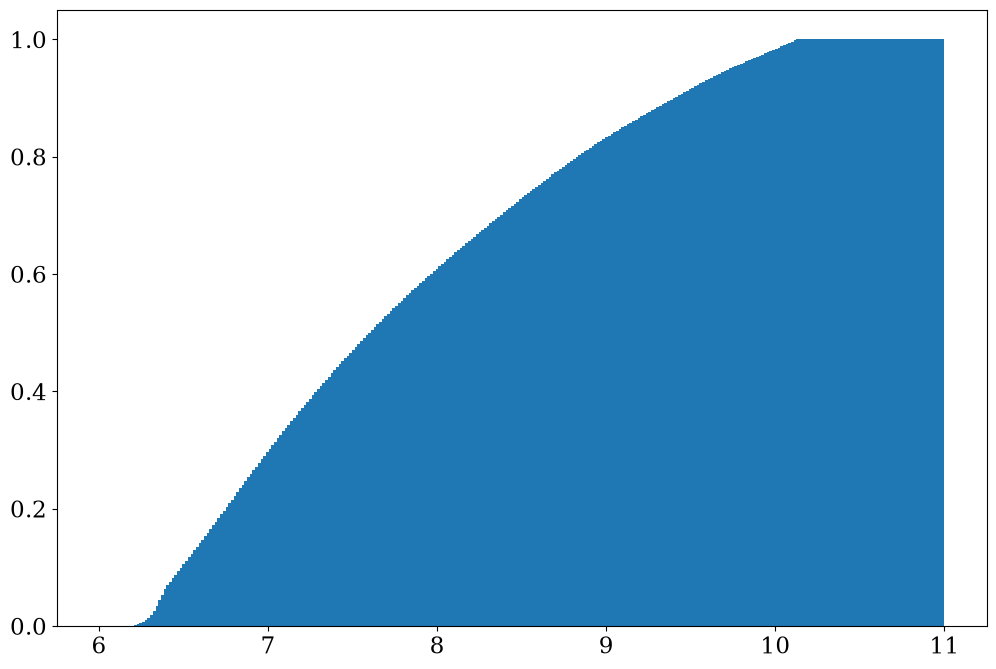

In [77]:
plt.hist(np.log10(merger_times.to(u.yr).value), bins="auto", cumulative=True, density=True, range=(6, 11))
plt.show()

# Test galaxy stuff

In [39]:
import sys
sys.path.append("../helpers")

from sfh import SB15PhiCut
import gala.potential as gp
import cogsworth
import matplotlib.pyplot as plt

In [68]:
class SB15PhiCut(cogsworth.sfh.SandersBinney2015):
    def __init__(self, phi_cut=0, *args, **kwargs):
        self.phi_cut = phi_cut
        super().__init__(*args, **kwargs)
        

    def _generate_df(self, J, component, tau):
        """Generate a distribution function for a given component and lookback time

        Follows `Sanders & Binney 2015 <https://ui.adsabs.harvard.edu/abs/2015MNRAS.449.3479S/abstract>`_
        Eq. 3.1.

        Parameters
        ----------
        J : `array-like`, shape (N, 3)
            Actions in (J_r, J_phi, J_z) in units of kpc^2 / Myr
        component : `str`
            Either "thin_disc" or "thick_disc"
        tau : :class:`~astropy.units.Quantity` [time]
            Lookback time

        Returns
        -------
        df_val : `array-like`, shape (N,)
            Value of the distribution function at the given actions
        """
        assert component in ["thin_disc", "thick_disc"], "Component must be 'thin_disc' or 'thick_disc'"

        J_r, J_z, J_phi = J.T

        # only compute the DF where the prior interpolations are valid
        df_val = np.zeros_like(J_r)
        valid = (J_phi >= 1e-5) & (J_phi <= 100)

        R_d = 3.45 if component == "thin_disc" else 2.31
        L_0 = 0.01

        # get guiding radii
        R_g = np.zeros_like(J_r)
        R_g[valid] = self._guiding_radius_interp(J_phi[valid])
        valid &= (R_g >= 1e-2) & (R_g <= 100)
        R_g = R_g[valid]

        # get frequencies at guiding radii based on potential
        omega = self._omega_interp(R_g)
        kappa = self._kappa_interp(R_g)
        nu = self._nu_interp(R_g)

        # time dependent velocity dispersions
        kms_to_kpcMyr = (u.km / u.s).to(u.kpc / u.Myr)
        sigma_R = self._get_sigma_i("R", R_g, tau, component) * kms_to_kpcMyr
        sigma_z = self._get_sigma_i("z", R_g, tau, component) * kms_to_kpcMyr

        # construct DF
        prefactor = 1 / (8 * np.pi**3) * (1 + np.tanh(J_phi[valid] / L_0))          # no units
        exp_terms = [
            omega / (R_d**2 * kappa**2) * np.exp(-R_g / R_d),                       # units of Myr/kpc^2
            (kappa / sigma_R**2) * np.exp(-kappa * J_r[valid] / sigma_R**2),        # units of Myr/kpc^2
            (nu / sigma_z**2) * np.exp(-nu * J_z[valid] / sigma_z**2)               # units of Myr/kpc^2
        ]
        df_val[valid] = prefactor * np.prod(exp_terms, axis=0)                      # units of Myr^3/kpc^6

        df_val[(J_phi < self.phi_cut)] = 0

        return df_val

In [69]:
regular = SB15PhiCut(phi_cut=0, potential=gp.MilkyWayPotential(version='v2'))
low_Z = SB15PhiCut(phi_cut=3.5, potential=gp.MilkyWayPotential(version='v2'))

In [151]:
uni, cnt = np.unique(all_formation_rows["metallicity"].values, return_counts=True)

In [152]:
np.sum([min(c * 10, 5_000) for c in cnt])

np.int64(213850)

In [148]:
rand_sample = all_formation_rows.sample(200_000)

In [149]:
Z_BIN_CENTRES = np.logspace(-4, np.log10(0.03), 50)
BIN_WIDTH = (np.log10(Z_BIN_CENTRES)[1] - np.log10(Z_BIN_CENTRES)[0]) / 2
Z_BIN_EDGES = np.logspace(np.log10(Z_BIN_CENTRES[0]) - BIN_WIDTH, np.log10(Z_BIN_CENTRES[-1]) + BIN_WIDTH, 51)
Z_BIN_EDGES[0] = Z_BIN_CENTRES[0]
Z_BIN_EDGES[-1] = Z_BIN_CENTRES[-1]

In [153]:
counts, _ = np.histogram(rand_sample["metallicity"].values, bins=Z_BIN_EDGES)
low_counts = counts.copy()
low_counts[30:] = 0
high_counts = counts.copy()
high_counts[:30] = 0

In [154]:
low_counts.sum()

np.int64(192940)

In [155]:
low_galaxy_counts = np.zeros_like(counts)
rnd = 0
while np.sum(low_galaxy_counts) < np.sum(low_counts):
    print(f"Round {rnd}: Current low galaxy counts: {np.sum(low_galaxy_counts)} / {np.sum(low_counts)}")
    print("  Missing counts per bin: ", low_counts - low_galaxy_counts)
    low_Z.sample(1_000_000)
    low_Z.Z[low_Z.Z < 1e-4] = 1e-4
    low_Z.Z[low_Z.Z > 0.03] = 0.03

    for i in range(len(low_counts)):
        if low_galaxy_counts[i] == low_counts[i]:
            continue

        matches = (Z_BIN_EDGES[i] <= low_Z.Z.value) & (low_Z.Z.value < Z_BIN_EDGES[i+1])
        low_galaxy_counts[i] = min(low_counts[i], low_galaxy_counts[i] + matches.sum())

    rnd += 1

Round 0: Current low galaxy counts: 0 / 192940
  Missing counts per bin:  [3474 3859 4501 4709 5524 6278 6800 7082 7381 7382 7873 7803 8000 7958
 7984 8107 8121 7991 7599 7506 7283 6996 6949 6538 6056 5633 5340 4812
 4059 3342    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
Round 1: Current low galaxy counts: 191359 / 192940
  Missing counts per bin:  [1581    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


In [119]:
rand_sample["metallicity"].values.min()

np.float64(0.0001)